<a href="https://colab.research.google.com/github/Dhlih/Submission-Dicoding-Analisis-Sentimen/blob/main/Pelatihan_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [109]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining

import numpy as np  # NumPy untuk komputasi numerik
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi
from sklearn.metrics import accuracy_score

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca

from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt_tab')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading Dataset

In [110]:
df = pd.read_csv("ulasan_ipusnas.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,82e83362-0763-4eab-9e3d-fc11930634a8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gabisa minjem, kesalahan pengiriman data mulu,...",1,124,2.1.0,2026-02-25 12:21:00,NaN,NaN,2.1.0
1,eb1e116f-41d2-4699-bee6-a86918bbd023,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kadang bisa minjem buku kadang engga, awalnya ...",2,234,2.1.0,2026-02-01 08:49:07,NaN,NaN,2.1.0
2,c28895ee-210a-4be9-81a3-7ad9c1a8b191,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Ini kenapa setelah update data peminjaman, ant...",2,369,2.0.6,2026-01-26 15:43:13,NaN,NaN,2.0.6
3,d6273ac9-49fc-4d54-a80f-d01210795215,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Halo ipusnas! Kenapa dari bulan Januari sampai...,3,31,2.1.0,2026-02-23 06:17:42,NaN,NaN,2.1.0
4,682da2e3-3176-4589-87bb-956495cf64a7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi ini tujuannya memudahkan akses baca s...,1,185,2.1.0,2026-02-22 07:15:35,NaN,NaN,2.1.0


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19959 entries, 0 to 19958
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              19959 non-null  object
 1   userName              19959 non-null  object
 2   userImage             19959 non-null  object
 3   content               19959 non-null  object
 4   score                 19959 non-null  int64 
 5   thumbsUpCount         19959 non-null  int64 
 6   reviewCreatedVersion  14981 non-null  object
 7   at                    19959 non-null  object
 8   replyContent          13130 non-null  object
 9   repliedAt             13130 non-null  object
 10  appVersion            14981 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.7+ MB


In [112]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,4978
at,0
replyContent,6829
repliedAt,6829


In [113]:
clean_df = df.dropna()
clean_df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,0
at,0
replyContent,0
repliedAt,0


In [114]:
clean_df.duplicated().sum()

np.int64(0)

## Preprocess Text

In [115]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [116]:
import json

with open('slang_words.json', 'r') as f:
    slang_words = json.load(f)

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slang_words:
            fixed_words.append(slang_words[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

# with open('stop_words.txt', 'r') as f:
#     stop_words = set(f.read().splitlines())

# def filteringText(text): # Menghapus stopwords dalam teks
#     filtered = []
#     for txt in text:
#         if txt not in stop_words:
#             filtered.append(txt)
#     text = filtered
#     return text

In [117]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_tokenizingText'].apply(toSentence)

In [118]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_akhir
23,d5f0a704-9260-47f4-960d-153ab64d6cf4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Setelah diupdate krn keperluan tugas, rupanya ...",1,46,2.0.6,2026-01-29 01:38:27,Hallo Liliy! Terima kasih sudah memberikan ula...,2022-03-27 08:52:58,2.0.6,Setelah diupdate krn keperluan tugas rupanya g...,setelah diupdate krn keperluan tugas rupanya g...,setelah diupdate karena keperluan tugas rupany...,"[setelah, diupdate, karena, keperluan, tugas, ...",setelah diupdate karena keperluan tugas rupany...
28,27609d0c-739b-4a34-847b-ff4a6a8c3fdc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya Download Aplikasi Ipusnas Langsung di Pla...,1,12,2.0.6,2026-01-25 02:42:18,Hallo Usman! Kami mohon maaf atas kendala dan ...,2023-04-01 11:01:42,2.0.6,Saya Download Aplikasi Ipusnas Langsung di Pla...,saya download aplikasi ipusnas langsung di pla...,saya download aplikasi ipusnas langsung di pla...,"[saya, download, aplikasi, ipusnas, langsung, ...",saya download aplikasi ipusnas langsung di pla...
33,96709d16-28e3-4dc9-aef2-7562a85b129e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Terima kasih sudah memberi kesempatan untuk ya...,2,3,2.0.6,2026-01-24 23:28:33,Hallo Puristi! Kami mohon maaf atas ketidaknya...,2024-09-09 01:34:17,2.0.6,Terima kasih sudah memberi kesempatan untuk ya...,terima kasih sudah memberi kesempatan untuk ya...,terima kasih sudah memberi kesempatan untuk ya...,"[terima, kasih, sudah, memberi, kesempatan, un...",terima kasih sudah memberi kesempatan untuk ya...
41,03dc5e28-0e6f-403a-87f1-694e00c29b5d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,astaga ipusnas... kenapa makin jelek aja sih.....,1,15,2.0.6,2026-01-29 23:28:07,Hallo Pujiana! Kami mohon maaf atas ketidaknya...,2023-10-01 07:16:16,2.0.6,astaga ipusnas kenapa makin jelek aja sih sebe...,astaga ipusnas kenapa makin jelek aja sih sebe...,astaga ipusnas kenapa makin jelek saja sih seb...,"[astaga, ipusnas, kenapa, makin, jelek, saja, ...",astaga ipusnas kenapa makin jelek saja sih seb...
54,b74d631a-0828-44db-bea5-8d459c8ca039,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Koleksi bukunya banyak banget! Meski harus nga...,5,2,2.1.0,2026-02-13 03:10:28,Hallo Pine! Kami mohon maaf atas kendala dan k...,2024-05-20 22:44:26,2.1.0,Koleksi bukunya banyak banget Meski harus ngan...,koleksi bukunya banyak banget meski harus ngan...,koleksi bukunya banyak banget meski harus meng...,"[koleksi, bukunya, banyak, banget, meski, haru...",koleksi bukunya banyak banget meski harus meng...


## Pelabelan

In [119]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
    for row in reader:
      # Mengulangi setiap baris dalam file CSV
      lexicon_positive[row[0]] = int(row[1])
      # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
      # Mengulangi setiap baris dalam file CSV
      lexicon_negative[row[0]] = int(row[1])
      # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [120]:
# Fungsi untuk menentukan polaritas sentimen dari tweet

def sentiment_analysis_lexicon_indonesia(text):
    #for word in text:
    score = 0
    # Inisialisasi skor sentimen ke 0
    # tidak perlu split karena text stopword berupa list
    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score >= 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
    # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan

    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [132]:
results = clean_df['text_tokenizingText'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))

clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]

In [133]:
# Mengubah label kategorikal menjadi numerik
label_mapping = {
    'negative': 0,
    'positive': 1,
}
clean_df["polarity_encoded"] = clean_df["polarity"].map(label_mapping)

In [134]:
clean_df["polarity"].value_counts()

,count
polarity,
negative,6972
positive,3093


([<matplotlib.patches.Wedge at 0x7b156812e7e0>,
 [Text(-0.6259792255233153, 0.9045164504934283, 'negative'),
  Text(0.6259795202521516, -0.9045162465234587, 'positive')],
 [Text(-0.3414432139218083, 0.4933726093600518, '69.3%'),
  Text(0.34144337468299174, -0.4933724981037047, '30.7%')])

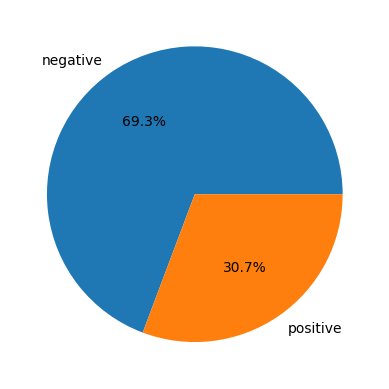

In [135]:
plt.pie(clean_df["polarity_encoded"].value_counts(), labels=clean_df["polarity"].value_counts().index, autopct='%1.1f%%')

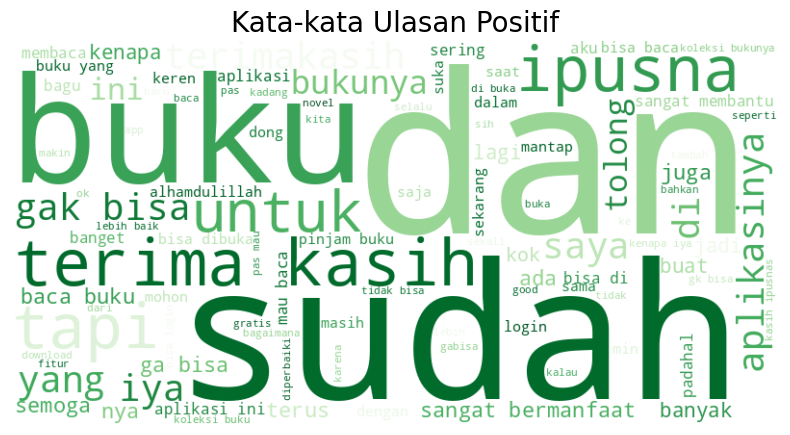

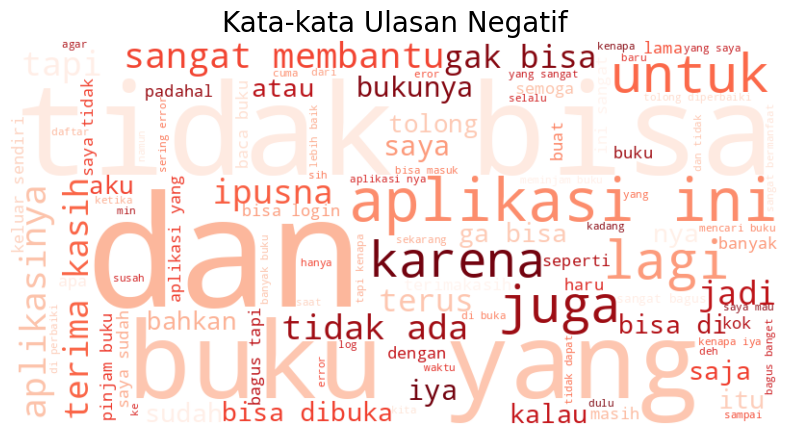

In [136]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. Pisahkan data berdasarkan polaritas
data_negatif = clean_df[clean_df['polarity_encoded'] == 0]['text_akhir']
data_positif = clean_df[clean_df['polarity_encoded'] == 1]['text_akhir']

# 2. Gabungkan semua baris teks menjadi satu string panjang
teks_negatif = " ".join(review for review in data_negatif)
teks_positif = " ".join(review for review in data_positif)

# 3. Fungsi untuk membuat Word Cloud
def buat_wordcloud(teks, judul, warna_peta):
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=warna_peta, # 'Greens' untuk positif, 'Reds' untuk negatif
        max_words=100
    ).generate(teks)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(judul, fontsize=20)
    plt.axis('off')

    plt.show()

# 4. Tampilkan Word Cloud Positif
buat_wordcloud(teks_positif, "Kata-kata Ulasan Positif", "Greens")

# 5. Tampilkan Word Cloud Negatif
buat_wordcloud(teks_negatif, "Kata-kata Ulasan Negatif", "Reds")

## Data Splitting dan Ekstraksi Fitur

In [137]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [138]:
# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity_encoded']

# Ekstraksi fitur dengan TF-IDF
# max_df = abaikan kata yang muncul lebih dari 80% total ulasan, min_df =  abaikan kata yang muncul kurang dari 17x
tfidf = TfidfVectorizer(max_features=2000, min_df=17, max_df=0.8, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Menampilkan hasil ekstraksi fitur
print("Shape dataframe : ", features_df.shape)
features_df

Shape dataframe :  (10065, 1983)


,ada,ada apa,ada aplikasi,ada banyak,ada beberapa,ada bug,ada buku,ada dan,ada data,ada di,...,yang sama,yang sangat,yang saya,yang sedang,yang sudah,yang suka,yang telah,yang tersedia,yang tidak,you
0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.099822,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.127536,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.134012,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.224656,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10060,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10061,0.214733,0.0,0.0,0.0,0.217871,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10062,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10063,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Pelatihan Model

### Logistic Regression

In [139]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression(class_weight="balanced")

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Linear Regression - accuracy_train:', accuracy_train_lr)
print('Linear Regression - accuracy_test:', accuracy_test_lr)

Linear Regression - accuracy_train: 0.9338052657724789
Linear Regression - accuracy_test: 0.9080973671137605


In [140]:
from sklearn.metrics import classification_report

labels = ['negatif', 'positif']

print("Classification Report:")
print(classification_report(y_test, y_pred_test_lr, target_names=labels))

Classification Report:
              precision    recall  f1-score   support

     negatif       0.96      0.90      0.93      1394
     positif       0.81      0.92      0.86       619

    accuracy                           0.91      2013
   macro avg       0.89      0.91      0.90      2013
weighted avg       0.91      0.91      0.91      2013



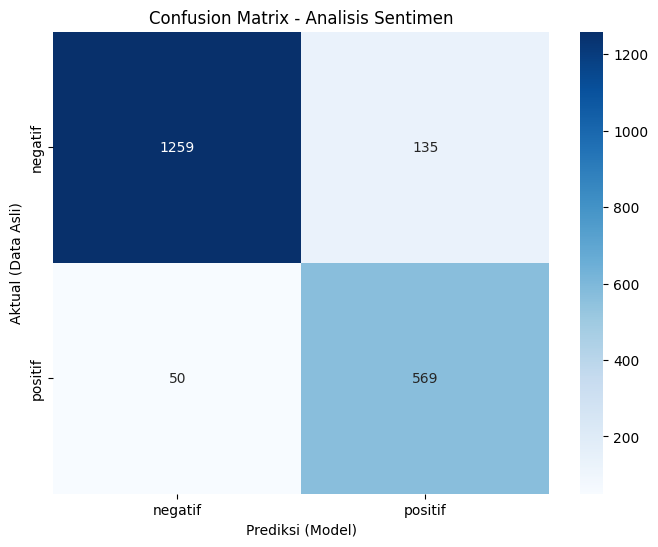

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Hitung Confusion Matrix
# Pastikan y_test (data asli) dan y_pred_test_lr (hasil prediksi) sudah tersedia
cm = confusion_matrix(y_test, y_pred_test_lr)

# 2. Visualisasi menggunakan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - Analisis Sentimen')
plt.xlabel('Prediksi (Model)')
plt.ylabel('Aktual (Data Asli)')
plt.show()

### Linear SVC

In [142]:
from sklearn.svm import LinearSVC

# LinearSVC cenderung lebih kuat untuk fitur TF-IDF yang banyak
model_svc = LinearSVC(class_weight='balanced', random_state=42)
model_svc.fit(X_train, y_train) # Tidak perlu .toarray(), SVC mendukung sparse matrix

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svc = model_svc.predict(X_train.toarray())
y_pred_test_svc = model_svc.predict(X_test.toarray())

# Evaluasi akurasi model Random Forest
accuracy_train_svc = accuracy_score(y_pred_train_svc, y_train)
accuracy_test_svc = accuracy_score(y_pred_test_svc, y_test)

# Menampilkan akurasi
print('Linear SVC - accuracy_train:', accuracy_train_svc)
print('Linear SVC - accuracy_test:', accuracy_test_svc)

Linear SVC - accuracy_train: 0.9751614505712867
Linear SVC - accuracy_test: 0.9215101838052657


In [143]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred_test_svc, target_names=labels))

Classification Report:
              precision    recall  f1-score   support

     negatif       0.96      0.92      0.94      1394
     positif       0.84      0.92      0.88       619

    accuracy                           0.92      2013
   macro avg       0.90      0.92      0.91      2013
weighted avg       0.92      0.92      0.92      2013



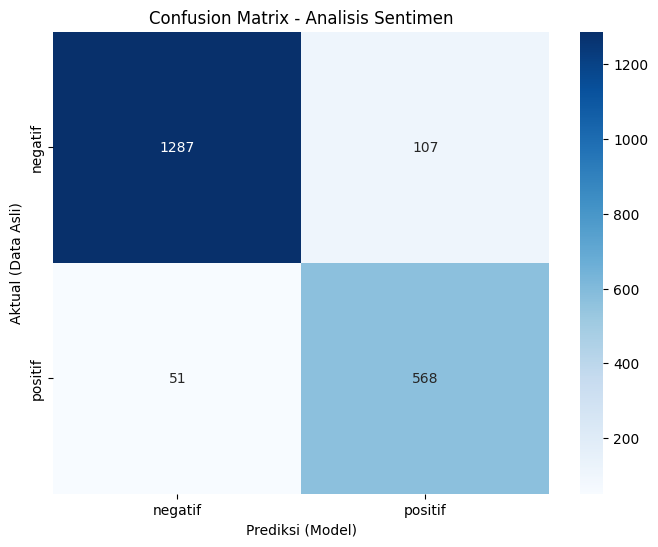

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Hitung Confusion Matrix
# Pastikan y_test (data asli) dan y_pred_test_lr (hasil prediksi) sudah tersedia
cm = confusion_matrix(y_test, y_pred_test_svc)

# 2. Visualisasi menggunakan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Confusion Matrix - Analisis Sentimen')
plt.xlabel('Prediksi (Model)')
plt.ylabel('Aktual (Data Asli)')
plt.show()

### Random Forests